# Exercise 09 - Tracking Human Movements in Video Streams

**Objective:** Upload your own video and track human movement using OpenCV.



In [1]:
# Common setup for Google Colab
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import base64
import pandas as pd
from IPython.display import HTML, display

plt.rcParams["figure.figsize"] = (10, 6)


def show_bgr(img, title="Image", size=(8, 5)):
    """Display a BGR/OpenCV image correctly in notebook."""
    plt.figure(figsize=size)
    if img is None:
        print("Image is empty / not loaded.")
        return
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def display_video(path, width=720):
    """Display an MP4 video inside Colab/Jupyter."""
    if not os.path.exists(path):
        print("Video file not found:", path)
        return
    with open(path, "rb") as f:
        video_data = f.read()
    encoded = base64.b64encode(video_data).decode("utf-8")
    return HTML(f"""
    <video width=\"{width}\" controls>
        <source src=\"data:video/mp4;base64,{encoded}\" type=\"video/mp4\">
        Your browser does not support the video tag.
    </video>
    """)


def resize_keep_aspect(frame, max_width=720):
    """Resize frame for faster Colab processing while keeping aspect ratio."""
    h, w = frame.shape[:2]
    if w <= max_width:
        return frame
    scale = max_width / w
    new_w = int(w * scale)
    new_h = int(h * scale)
    return cv2.resize(frame, (new_w, new_h))


def video_info(path):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        raise ValueError("Could not open video. Try uploading MP4/AVI/MOV/MKV.")
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 0:
        fps = 25
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps if fps else 0
    cap.release()
    return fps, frame_count, width, height, duration

print("OpenCV version:", cv2.__version__)


OpenCV version: 4.13.0


## Step 1: Upload your own video

Upload a video where a person is moving. Supported formats usually include **MP4, AVI, MOV, MKV**.

For best result:

- Use a video with a mostly fixed camera
- Keep the person clearly visible
- Avoid too much camera shake
- Use decent lighting


Saving video.mp4 to video.mp4
Uploaded video: video.mp4

Video Details
-------------
FPS: 29.97
Resolution: 478 x 850
Total frames: 153
Duration: 5.1 seconds


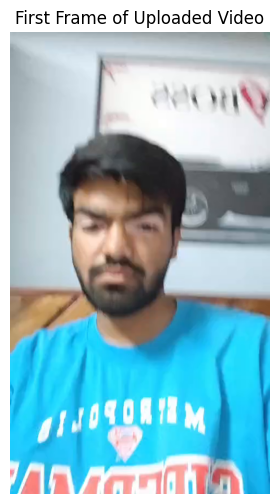

In [2]:
# Upload your own video from computer
from google.colab import files

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No video uploaded. Please run this cell again and upload a video.")

VIDEO_PATH = list(uploaded.keys())[0]
print("Uploaded video:", VIDEO_PATH)

fps, total_frames, original_width, original_height, duration = video_info(VIDEO_PATH)

print("\nVideo Details")
print("-------------")
print("FPS:", round(fps, 2))
print("Resolution:", original_width, "x", original_height)
print("Total frames:", total_frames)
print("Duration:", round(duration, 2), "seconds")

# Preview first frame
cap = cv2.VideoCapture(VIDEO_PATH)
ret, first_frame = cap.read()
cap.release()

if not ret:
    raise ValueError("Could not read the first frame from the uploaded video.")

first_frame_preview = resize_keep_aspect(first_frame, max_width=720)
show_bgr(first_frame_preview, "First Frame of Uploaded Video", size=(10, 6))


## Step 2: Track human movement using background subtraction

This cell detects moving regions, draws bounding boxes, and creates a trail showing the movement path.

You can adjust these settings:

- `MAX_OUTPUT_WIDTH`: smaller means faster processing
- `MIN_AREA`: increase if small noise is detected, decrease if the person is not detected
- `MAX_SECONDS`: set to a number like `20` to process only first 20 seconds; keep `None` for full video


In [3]:
# -----------------------------
# Settings you can adjust
# -----------------------------
MAX_OUTPUT_WIDTH = 720     # Resize wide videos for faster processing
MIN_AREA = 900             # Minimum moving object area
MAX_SECONDS = None         # Example: 20 for first 20 sec, None for full video

# Output files
OUTPUT_VIDEO = "tracked_uploaded_human_movement.mp4"
OUTPUT_PATH_IMAGE = "human_movement_path.png"
OUTPUT_CSV = "tracking_points.csv"

cap = cv2.VideoCapture(VIDEO_PATH)
input_fps = cap.get(cv2.CAP_PROP_FPS)
if input_fps is None or input_fps <= 0:
    input_fps = fps

# Read first frame to determine output size
ret, sample_frame = cap.read()
if not ret:
    cap.release()
    raise ValueError("Could not read video frames.")

sample_frame = resize_keep_aspect(sample_frame, max_width=MAX_OUTPUT_WIDTH)
out_height, out_width = sample_frame.shape[:2]
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, input_fps, (out_width, out_height))

# Background subtraction model
bg = cv2.createBackgroundSubtractorMOG2(
    history=120,
    varThreshold=40,
    detectShadows=True
)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
track_points = []
tracking_rows = []
first_output_frame = sample_frame.copy()

frame_index = 0
max_frames_to_process = None
if MAX_SECONDS is not None:
    max_frames_to_process = int(MAX_SECONDS * input_fps)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if max_frames_to_process is not None and frame_index >= max_frames_to_process:
        break

    frame = resize_keep_aspect(frame, max_width=MAX_OUTPUT_WIDTH)

    # Foreground mask
    fg = bg.apply(frame)

    # Remove shadow pixels and keep strong foreground only
    _, fg = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)

    # Clean the mask
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel, iterations=1)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel, iterations=2)
    fg = cv2.dilate(fg, kernel, iterations=2)

    contours, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [cnt for cnt in contours if cv2.contourArea(cnt) >= MIN_AREA]
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    if len(contours) > 0:
        # Main tracked moving person/object = largest contour
        largest = contours[0]
        area = cv2.contourArea(largest)
        x, y, w, h = cv2.boundingRect(largest)
        cx, cy = x + w // 2, y + h // 2

        track_points.append((cx, cy))
        tracking_rows.append({
            "frame": frame_index,
            "time_sec": round(frame_index / input_fps, 2),
            "center_x": cx,
            "center_y": cy,
            "bbox_x": x,
            "bbox_y": y,
            "bbox_w": w,
            "bbox_h": h,
            "area": round(area, 2)
        })

        # Draw largest tracked person
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.circle(frame, (cx, cy), 6, (0, 0, 255), -1)
        cv2.putText(frame, "Tracked Movement", (x, max(25, y - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # Draw extra moving regions lightly, if present
        for cnt in contours[1:4]:
            x2, y2, w2, h2 = cv2.boundingRect(cnt)
            cv2.rectangle(frame, (x2, y2), (x2 + w2, y2 + h2), (255, 180, 0), 2)

    # Draw complete movement trail
    for j in range(1, len(track_points)):
        cv2.line(frame, track_points[j - 1], track_points[j], (255, 255, 0), 2)

    cv2.putText(frame, f"Frame: {frame_index}", (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    writer.write(frame)
    frame_index += 1

cap.release()
writer.release()

# Save tracking data
tracking_df = pd.DataFrame(tracking_rows)
tracking_df.to_csv(OUTPUT_CSV, index=False)

print("Processing completed!")
print("Frames processed:", frame_index)
print("Tracked positions:", len(track_points))
print("Output video:", OUTPUT_VIDEO)
print("Tracking CSV:", OUTPUT_CSV)

if len(track_points) == 0:
    print("\nNo movement was detected. Try decreasing MIN_AREA or use a clearer video.")
else:
    display(display_video(OUTPUT_VIDEO, width=720))


Processing completed!
Frames processed: 153
Tracked positions: 144
Output video: tracked_uploaded_human_movement.mp4
Tracking CSV: tracking_points.csv


## Step 3: Show movement path / trajectory

This creates a still image showing the overall direction of movement.


Movement path image saved: human_movement_path.png


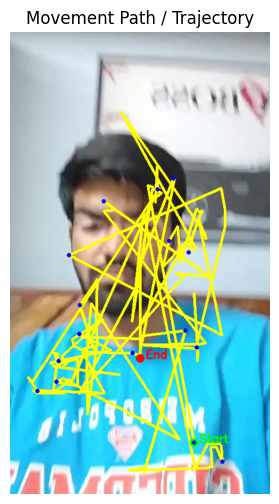

In [4]:
if len(track_points) > 0:
    path_img = first_output_frame.copy()

    for j in range(1, len(track_points)):
        cv2.line(path_img, track_points[j - 1], track_points[j], (0, 255, 255), 3)

    # Mark some important points along the path
    cv2.circle(path_img, track_points[0], 8, (0, 255, 0), -1)
    cv2.putText(path_img, "Start", (track_points[0][0] + 10, track_points[0][1]),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    cv2.circle(path_img, track_points[-1], 8, (0, 0, 255), -1)
    cv2.putText(path_img, "End", (track_points[-1][0] + 10, track_points[-1][1]),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    for p in track_points[::max(1, len(track_points)//15)]:
        cv2.circle(path_img, p, 4, (255, 0, 0), -1)

    cv2.imwrite(OUTPUT_PATH_IMAGE, path_img)
    print("Movement path image saved:", OUTPUT_PATH_IMAGE)
    show_bgr(path_img, "Movement Path / Trajectory", size=(10, 6))
else:
    print("No trajectory to show because no movement points were detected.")


## Step 4: Optical flow visualization

Optical flow shows how visual features move from one frame to the next.


Optical flow image saved: optical_flow_result.png


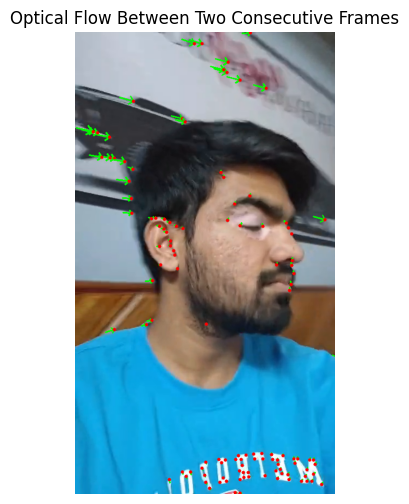

In [5]:
OPTICAL_FLOW_IMAGE = "optical_flow_result.png"

cap = cv2.VideoCapture(VIDEO_PATH)

# Pick two consecutive frames from around 35% of the video
if total_frames >= 2:
    start_idx = min(max(0, int(total_frames * 0.35)), total_frames - 2)
else:
    start_idx = 0

frames = []
for target_index in [start_idx, start_idx + 1]:
    cap.set(cv2.CAP_PROP_POS_FRAMES, target_index)
    ret, frame = cap.read()
    if ret:
        frames.append(resize_keep_aspect(frame, max_width=MAX_OUTPUT_WIDTH))
cap.release()

if len(frames) == 2:
    old_gray = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY)
    new_gray = cv2.cvtColor(frames[1], cv2.COLOR_BGR2GRAY)

    p0 = cv2.goodFeaturesToTrack(
        old_gray,
        maxCorners=120,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7
    )

    if p0 is None:
        print("No strong feature points found for optical flow. Try another video/frame.")
    else:
        p1, status, error = cv2.calcOpticalFlowPyrLK(old_gray, new_gray, p0, None)

        flow_img = frames[1].copy()
        good_new = p1[status == 1]
        good_old = p0[status == 1]

        for new, old in zip(good_new, good_old):
            a, b = new.ravel().astype(int)
            c, d = old.ravel().astype(int)
            cv2.arrowedLine(flow_img, (c, d), (a, b), (0, 255, 0), 2, tipLength=0.4)
            cv2.circle(flow_img, (a, b), 3, (0, 0, 255), -1)

        cv2.imwrite(OPTICAL_FLOW_IMAGE, flow_img)
        print("Optical flow image saved:", OPTICAL_FLOW_IMAGE)
        show_bgr(flow_img, "Optical Flow Between Two Consecutive Frames", size=(10, 6))
else:
    print("Could not read two consecutive frames for optical flow.")


## Step 5: Download output files

This downloads the processed output video, movement path image, optical flow image, and tracking CSV.


In [6]:
from google.colab import files

for file_name in [OUTPUT_VIDEO, OUTPUT_PATH_IMAGE, OPTICAL_FLOW_IMAGE, OUTPUT_CSV]:
    if os.path.exists(file_name):
        print("Downloading:", file_name)
        files.download(file_name)
    else:
        print("File not found, skipped:", file_name)


Downloading: tracked_uploaded_human_movement.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: human_movement_path.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: tracking_points.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Result

The uploaded video was processed using OpenCV. The notebook generated:

- A tracked output video with bounding box and movement trail
- A trajectory image showing start-to-end movement
- An optical flow visualization
- A CSV file containing tracked center points frame-by-frame
